<a href="https://colab.research.google.com/github/Ayush5727t/aps-google-colab/blob/main/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimum Cost Spanning Tree
Problem Description:
A spanning tree of a graph can be defined as a graph with minimal set of edges that connect all vertices. A minimum spanning tree of a graph is a spanning tree of the graph with least weight (where the weight is computed by adding the weights of all the edges in the spanning tree). In general, a graph can have multiple minimum spanning trees. The problem is to find a minimum spanning tree of a graph.

This implementation uses a dictionary to represent the weighted graph, where the vertices are keys, and the values are dictionaries containing their adjacent vertices and their weights.

Please note that this implementation assumes that the input graph is connected and weighted.

First, let's create a simple graph to demonstrate Prim's algorithm:

In [1]:
graph = {
    "A": {"B": 10, "C": 15, "D": 20},
    "B": {"A": 10, "C": 12},
    "C": {"A": 15, "B": 12, "D": 18},
    "D": {"A": 20, "C": 18},
}
print(list(graph.keys())[1])

B


In [2]:
map={}
for _ in range(5):
  map[_,_]=_,_
print(map)

{(0, 0): (0, 0), (1, 1): (1, 1), (2, 2): (2, 2), (3, 3): (3, 3), (4, 4): (4, 4)}


Now, let's implement Prim's algorithm:

In [3]:
def prim_algorithm(graph):
    min_tree = {}
    visited = set()
    min_tree[list(graph.keys())[0]] = []
    min_weight = 0

    while len(visited) < len(graph):
        min_edge = float('inf')
        next_vertex = None
        for vertex in min_tree:
            for adj_vertex, weight in graph[vertex].items():
                if adj_vertex not in visited:
                    if weight < min_edge:
                        min_edge = weight
                        next_vertex = adj_vertex

        min_tree[next_vertex] = []
        visited.add(next_vertex)
        min_weight += min_edge

    return min_tree, min_weight

Now, let's run the Prim's algorithm on the example graph:
Keep in mind that this example uses a simple representation of a graph, but for more complex cases, you might want to use a library such as NetworkX to represent and manipulate graphs.

In [4]:
mst, min_weight = prim_algorithm(graph)
print("Minimum Spanning Tree: ", mst)
print("Minimum Weight: ", min_weight)

Minimum Spanning Tree:  {'A': [], 'B': [], 'C': [], 'D': []}
Minimum Weight:  50


Take Differnt example of input graph as discussed in lecture slide and use above code to verify the output

Use same apporach for Kruskal's algorithm

In [10]:
class DisjointSet:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, u):
        if self.parent[u] != u:
            # Path compression: directly link node to root
            self.parent[u] = self.find(self.parent[u])
        return self.parent[u]

    def union(self, u, v):
        root_u = self.find(u)
        root_v = self.find(v)
        if root_u != root_v:
            # Union by rank: attach smaller tree under larger tree
            if self.rank[root_u] > self.rank[root_v]:
                self.parent[root_v] = root_u
            elif self.rank[root_u] < self.rank[root_v]:
                self.parent[root_u] = root_v
            else:
                self.parent[root_v] = root_u
                self.rank[root_u] += 1
            return True
        return False

def kruskal(num_vertices, edges):
    # Sort all edges in non-decreasing order of their weight
    edges.sort(key=lambda x: x[2])

    ds = DisjointSet(num_vertices)
    mst = []
    total_weight = 0

    for u, v, weight in edges:
        # If adding the edge doesn't form a cycle, include it
        if ds.union(u, v):
            mst.append((u, v, weight))
            total_weight += weight
            # Stop once we've reached (V - 1) edges
            if len(mst) == num_vertices - 1:
                break

    return mst, total_weight

# --- Hardcoded Input ---
# Defining a graph with 4 vertices (0, 1, 2, 3)
# Edge format: (source, destination, weight)
num_vertices = 4
graph_edges = [
    (0, 1, 10),
    (0, 2, 6),
    (0, 3, 5),
    (1, 3, 15),
    (2, 3, 4)
]

# Run the algorithm
mst_result, total_mst_weight = kruskal(num_vertices, graph_edges)

# Output the results
print("Edges in Minimum Spanning Tree (u, v, weight):")
for u, v, w in mst_result:
    print(f"{u} -- {v} with weight {w}")
print(f"Total MST Weight: {total_mst_weight}")


Edges in Minimum Spanning Tree (u, v, weight):
2 -- 3 with weight 4
0 -- 3 with weight 5
0 -- 1 with weight 10
Total MST Weight: 19


[[0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


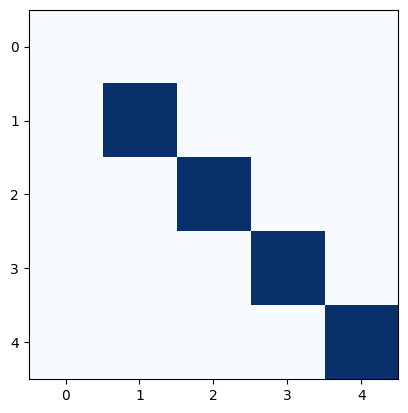

In [ ]:
#simple graph adj matrix
import numpy as np
import matplotlib.pyplot as plt

def graph(v,edges):
  mat=np.zeros((v,v))
  #edge conf
  for edge in edges:
    u=edge[0]
    v=edge[1]
    mat[u][v]=1
    mat[v][u] = 1
  return mat
v=5
edges=[[1,1],[2,2],[3,3],[4,4]]
matrix=graph(v,edges)
print(matrix)
plt.imshow(matrix , cmap='Blues' , interpolation='none')

In [ ]:
a=np.zeros([5,5])
print(a)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [ ]:
def createGraph(V, edges):
    adj = [[] for _ in range(V)]

    # Add each edge to the adjacency list
    for it in edges:
        u = it[0]
        v = it[1]
        adj[u].append(v)

         # since the graph is undirected
        adj[v].append(u)
    return adj
V=5
edges=[[1,1],[2,2],[3,3],[4,4]]
m=createGraph(V,edges)
print(m)

[[], [1, 1], [2, 2], [3, 3], [4, 4]]


In [ ]:
print("Adjacency List Representation:")
for i in range(V):

        # Print the vertex
  print(f"{i}:", end=" ")
  for j in m[i]:

            # Print its adjacent
    print(j, end=" ")
    print()

Adjacency List Representation:
0: 1: 1 
1 
2: 2 
2 
3: 3 
3 
4: 4 
4 
